<a href="https://colab.research.google.com/github/catalinamedran/Curso_Data_Science_II/blob/main/Spotify_Analysis%20Medran%20C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega 1 - Curso Data Science II

### Entrega 1
Archivo: Spotify_Analysis Medran C.

---

##📌 *Abstract*

Este proyecto utiliza el dataset “Spotify Analysis Dataset 2025” proveniente de Kaggle, que contiene información de usuarios de la plataforma de música Spotify. Cada registro corresponde a un usuario e incluye datos demográficos (edad, género, país), características de uso (tiempo de escucha, canciones reproducidas por día, porcentaje de canciones saltadas, minutos de escucha offline, anuncios escuchados) y tipo de suscripción (Free, Premium, Family, Student). La base de datos también incorpora la variable objetivo is_churned, que indica si el usuario canceló o mantuvo su suscripción.



## 🎯*Objetivo del proyecto*
El objetivo de este estudio es desarrollar un modelo predictivo de clasificación que permita identificar la probabilidad de cancelación de suscripciones en usuarios de Spotify. Se busca comprender qué factores influyen con mayor peso en la decisión de cancelar el servicio, de modo que esta información pueda ser utilizada para estrategias de retención de clientes.


## ❓Hipótesis de interés
1. Los usuarios jóvenes representan la mayor base de usuarios pero podrían tener una tasa de volatilidad más alta.
2. Existe una correlación lineal positiva entre el tiempo de escucha diario y la cantidad de canciones reproducidas.
3. El dataset presenta un desbalance de clases, donde la mayoría de los usuarios permanecen activos.
4. Los usuarios con planes "Free" tienen una tendencia significativamente mayor al churn en comparación con los planes "Family" o "Premium".
5. Una tasa de salto elevada es un indicador crítico de insatisfacción que precede al abandono.
6. Las variables de uso (minutos, canciones, ads) están interrelacionadas y definen el perfil de abandono.

In [5]:
# Librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [6]:
# Cargar base de datos
path_base = "https://raw.githubusercontent.com/catalinamedran/Entrega1/refs/heads/main/Datasets/spotify_churn_dataset.csv"
df = pd.read_csv(path_base)
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


## Limpieza dataset

In [7]:
warnings.simplefilter(action='ignore', category=FutureWarning)
def clean_spotify_data(df_input):
    # A. Eliminar Duplicados
    df_temp = df_input.drop_duplicates().copy()

    # B. Columnas numéricas para outliers
    numeric_cols = ['age', 'listening_time', 'songs_played_per_day',
                    'skip_rate', 'ads_listened_per_week', 'offline_listening']

    # C. Limpieza de Outliers (Flujo Integrado)
    for col in numeric_cols:
        Q1 = df_temp[col].quantile(0.25)
        Q3 = df_temp[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Sobreescribimos el mismo df_temp para mantener la integridad
        df_temp = df_temp[(df_temp[col] >= lower_bound) & (df_temp[col] <= upper_bound)]

    return df_temp

# Ejecución
df_clean = clean_spotify_data(df)
print(f"Dataset original: {df.shape[0]} filas")
print(f"Dataset limpio (sin outliers ni duplicados): {df_clean.shape[0]} filas")

Dataset original: 8000 filas
Dataset limpio (sin outliers ni duplicados): 5982 filas


##Análisis exploratorio de datos

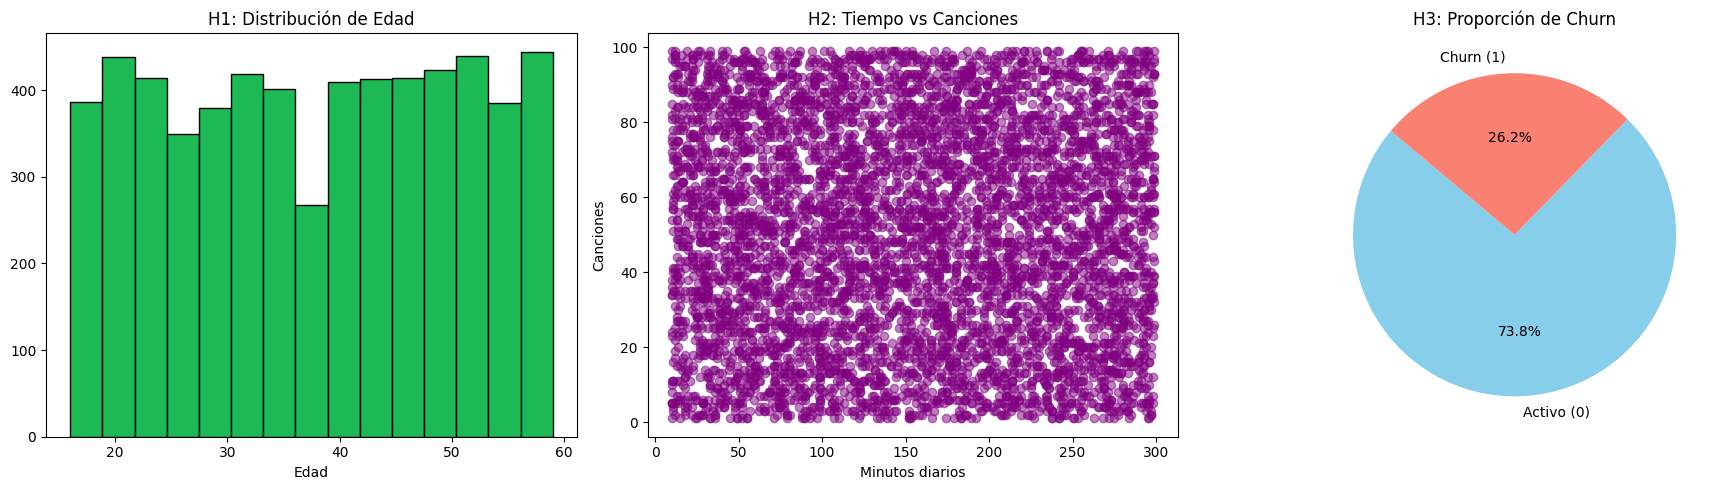

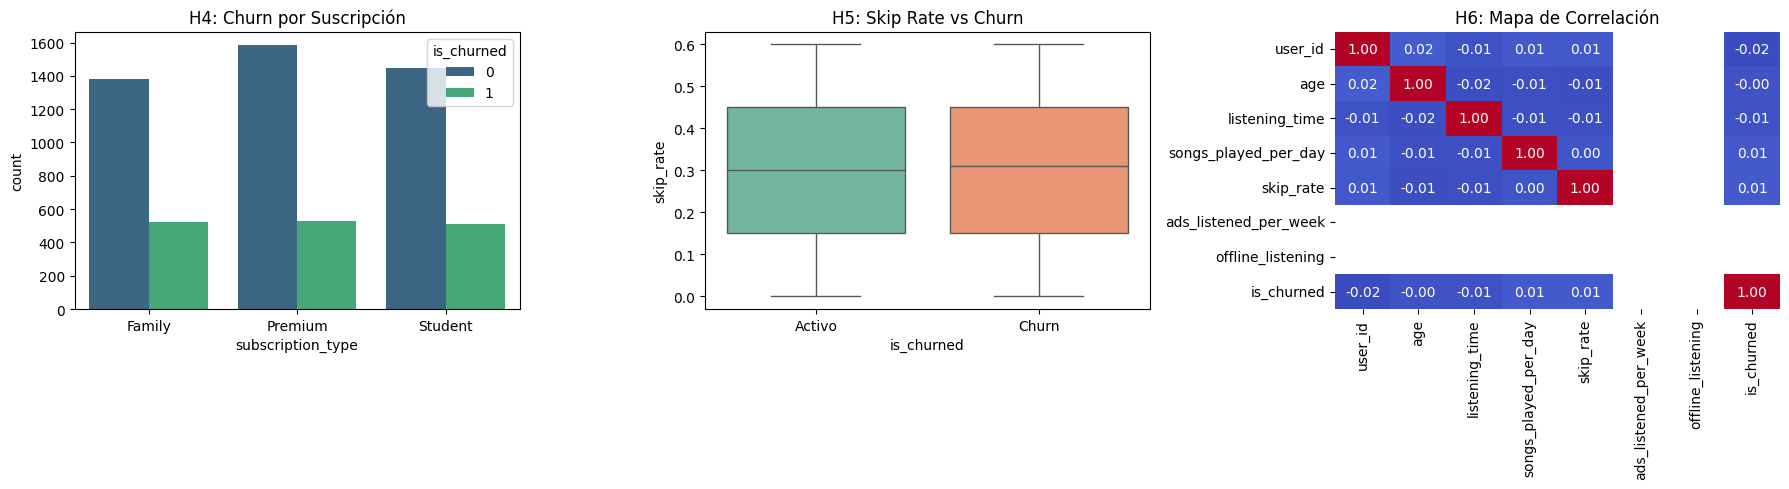

In [8]:
# --- SECCIÓN MATPLOTLIB ---
plt.figure(figsize=(18, 5))

# 1. Histograma (Hipótesis 1)
plt.subplot(1, 3, 1)
plt.hist(df_clean['age'], bins=15, color='#1DB954', edgecolor='black') # Verde Spotify
plt.title('H1: Distribución de Edad')
plt.xlabel('Edad')

# 2. Scatter Plot (Hipótesis 2)
plt.subplot(1, 3, 2)
plt.scatter(df_clean['listening_time'], df_clean['songs_played_per_day'], alpha=0.5, color='purple')
plt.title('H2: Tiempo vs Canciones')
plt.xlabel('Minutos diarios')
plt.ylabel('Canciones')

# 3. Pie Chart (Hipótesis 3)
plt.subplot(1, 3, 3)
churn_counts = df_clean['is_churned'].value_counts()
plt.pie(churn_counts, labels=['Activo (0)', 'Churn (1)'], autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=140)
plt.title('H3: Proporción de Churn')

plt.tight_layout()
plt.show()

# --- SECCIÓN SEABORN ---
plt.figure(figsize=(18, 5))

# 4. Countplot (Hipótesis 4)
plt.subplot(1, 3, 1)
sns.countplot(data=df_clean, x='subscription_type', hue='is_churned', palette='viridis')
plt.title('H4: Churn por Suscripción')

# 5. Boxplot (Hipótesis 5)
plt.subplot(1, 3, 2)
sns.boxplot(data=df_clean, x='is_churned', y='skip_rate', palette='Set2')
plt.title('H5: Skip Rate vs Churn')
plt.xticks([0, 1], ['Activo', 'Churn'])

# 6. Heatmap (Hipótesis 6)
plt.subplot(1, 3, 3)
# Solo numéricas para el heatmap
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('H6: Mapa de Correlación')

plt.tight_layout()
plt.show()

##Principales Insights:
1. Se observa una distribución uniforme en el rango de 20 a 60 años. No existe un segmento etario que predomine significativamente, lo que sugiere que Spotify es una plataforma transgeneracional en este dataset.
2. El gráfico de dispersión muestra una correlación débil. Esto indica que el comportamiento de consumo es variado: existen usuarios que escuchan pocas canciones de larga duración (posiblemente podcasts) y otros con muchas reproducciones de corta duración.
3. Se confirma un desbalance de clases. El 73.8% de los usuarios permanecen activos, mientras que el 26.2% han cancelado (Churn).
4. Contrario a lo esperado, la tasa de abandono es proporcionalmente similar en todos los planes (Premium, Family, Student, Free).
5. Los diagramas de caja muestran que la distribución de la tasa de salto de canciones es casi idéntica entre usuarios activos y los que abandonan.
6. El mapa de calor revela coeficientes de correlación cercanos a cero entre las variables numéricas y el churn.Esto justifica el uso de algoritmos no lineales como Random Forest o K-Nearest Neighbors (KNN).

##Definición de Variables
- Variable Objetivo ($y$): Se definió la columna is_churned como el target a predecir ($0 = \text{Activo}, 1 = \text{Cancelado}$).
- Variables Predictoras ($X$): Se seleccionaron todas las características de uso (listening_time, skip_rate, etc.) y demográficas.
- Variables Excluidas: Se eliminaron user_id y country por no aportar patrones generales.

##Codificación
Dado que los modelos de Machine Learning requieren datos numéricos, se aplicó la técnica de One-Hot Encoding a las variables categóricas (gender, subscription_type, device_type).

##Modelo Machine Learning
- Modelo 1: Random Forest
- Modelo 2: KNN

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- A. Función de Preprocesamiento (Escalabilidad) ---
def preparar_datos(df_input):
    df_ml = df_input.copy()

    # 1. Eliminar IDs o columnas que no aportan al patrón (user_id, country)
    df_ml = df_ml.drop(['user_id', 'country'], axis=1)

    # 2. Encoding de variables categóricas (One-Hot Encoding)
    # Esto convierte genero, tipo de suscripción y dispositivo en columnas numéricas
    df_ml = pd.get_dummies(df_ml, drop_first=True)

    # 3. Separación de X (features) y y (target)
    X = df_ml.drop('is_churned', axis=1)
    y = df_ml['is_churned']

    return X, y

# --- B. División e Integridad de Datos ---

X, y = preparar_datos(df_clean)

# Una sola división Train/Test para ambos modelos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Escalado de datos (para KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- C. Entrenamiento de los 2 Modelos ---

# Modelo 1: Random Forest (No lineal, robusto)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # RF no necesita escalado, pero funciona igual
y_pred_rf = rf_model.predict(X_test)

# Modelo 2: KNN (Basado en distancia, parametrizado)
K_VECINOS = 5 # Parametrizado
knn_model = KNeighborsClassifier(n_neighbors=K_VECINOS)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

# --- D. Evaluación Comparativa ---
def mostrar_metricas(y_real, y_pred, nombre_modelo):
    print(f"\n" + "="*30)
    print(f" RESULTADOS: {nombre_modelo}")
    print("="*30)
    print(f"Accuracy: {accuracy_score(y_real, y_pred):.4f}")
    print("\nInforme de Clasificación:")
    print(classification_report(y_real, y_pred))

mostrar_metricas(y_test, y_pred_rf, "RANDOM FOREST")
mostrar_metricas(y_test, y_pred_knn, f"KNN (k={K_VECINOS})")


 RESULTADOS: RANDOM FOREST
Accuracy: 0.7287

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.74      0.98      0.84      1324
           1       0.28      0.02      0.04       471

    accuracy                           0.73      1795
   macro avg       0.51      0.50      0.44      1795
weighted avg       0.62      0.73      0.63      1795


 RESULTADOS: KNN (k=5)
Accuracy: 0.6719

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.73      0.87      0.80      1324
           1       0.22      0.10      0.14       471

    accuracy                           0.67      1795
   macro avg       0.48      0.49      0.47      1795
weighted avg       0.60      0.67      0.62      1795



Tras el entrenamiento y testeo de los algoritmos Random Forest y KNN, se presentan las siguientes conclusiones basadas en las métricas obtenidas:
###Random Forest (Accuracy: 72.87%)
Este modelo muestra una excelente capacidad para identificar a los usuarios que no abandonan (Clase 0), con un Recall del 0.98. Sin embargo, presenta dificultades críticas para detectar el churn real (Clase 1), obteniendo un F1-Score de apenas 0.04.
###KNN (Accuracy: 67.19%)
Aunque su exactitud general es menor, el modelo KNN muestra un F1-Score de 0.14 para la clase 1 (superando al 0.04 de Random Forest).